# Lab 4: Model-Based Offline Optimization

In this lab, we explore **Model-Based Offline Optimization (MBO)**, a method to optimize black-box functions using only a pre-collected dataset, without additional function evaluations. We'll use two functions from the **Black-Box Optimization Benchmarking (BBOB)** suite:
- **f1** [Sphere Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=5): A simple, unimodal function with a global minimum at (0, 0).
- **f22** [Gallagher's Gaussian 21-hi Peaks Function](https://numbbo.github.io/gforge/downloads/download16.00/bbobdocfunctions.pdf#page=110): A complex, multimodal function with many local optima.

Visualizations of these problems are available [here](https://coco-platform.org/testsuites/bbob/viz.html?col=3&dim=2&fun=1&ins=1&typ=all).

### Objectives
1. **Dataset:** Use pre-collected datasets (100k samples each) for f1 and f22, generated via **Latin Hypercube Sampling (LHS)** [learn more about LHS here](https://en.wikipedia.org/wiki/Latin_hypercube_sampling).
2. **Surrogate Model:** Train a Multi-Layer Perceptron (MLP) to approximate these functions.
3. **Visualization:** Compare the MLP's predictions to the true functions using contour and scatter plots.
4. **Optimization:** Implement gradient-based optimization on the MLP to find optimal points.
5. **Experiments:** Investigate how training dataset size and model complexity affect performance.

### Key Concepts
- **Offline Optimization:** No new evaluations of the true function are allowed; we rely solely on the dataset.
- **Surrogate Model:** The MLP acts as a cheap, differentiable proxy for the expensive black-box function.
- **Gradient-Based Optimization:** Use the MLP's gradients to find optimal designs efficiently.

In [1]:
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import pandas as pd

device = torch.device(
    "cuda"
    if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available() else "cpu"
)

### 1. Data Preparation

We start by loading and splitting the dataset into training, validation, and test sets.

In [2]:
def prepare_dataloaders(
    file_path: str,
    batch_size: int = 256,
    train_perc: float = 0.6,
    val_perc: float = 0.2,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    """
    Prepare train, validation and test dataloaders.

    Args:
        file_path: Path to CSV data file
        batch_size: Batch size for dataloaders
        train_perc: Percentage of data for training
        val_perc: Percentage of data for validation
    """
    # Load data
    data_df = pd.read_csv(file_path)
    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    # Split data
    num_samples = len(X)
    indices = np.random.permutation(num_samples)
    train_size = int(train_perc * num_samples)
    val_size = int(val_perc * num_samples)

    # Create datasets
    train_dataset = TensorDataset(X[indices[:train_size]], y[indices[:train_size]])
    val_dataset = TensorDataset(
        X[indices[train_size : train_size + val_size]],
        y[indices[train_size : train_size + val_size]],
    )
    test_dataset = TensorDataset(
        X[indices[train_size + val_size :]], y[indices[train_size + val_size :]]
    )

    # Create dataloaders
    train_dataloader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_dataloader = DataLoader(val_dataset, batch_size=batch_size)
    test_dataloader = DataLoader(test_dataset, batch_size=batch_size)

    return train_dataloader, val_dataloader, test_dataloader

# Example usage (replace with your file path)
train_dataloader, val_dataloader, test_dataloader = prepare_dataloaders(
    "./bbob_f022_i01_d02_samples.csv", train_perc=0.3, val_perc=0.4
)

### 2. Define the MLP Model

The MLP will serve as our surrogate model to approximate the black-box function.

In [3]:
class MLP(nn.Module):
    def __init__(
        self, input_dim: int = 2, hidden_dim: int = 256, n_layers: int = 3
    ) -> None:
        """
        Multi-Layer Perceptron (MLP) for function approximation.

        Args:
            input_dim (int): Number of input features (e.g., 2 for x1, x2).
            hidden_dim (int): Number of neurons in each hidden layer.
            n_layers (int): Total number of layers (input + hidden + output).
        """
        super(MLP, self).__init__()

        layers = []
        # Input layer
        layers.append(nn.Linear(input_dim, hidden_dim))
        layers.append(nn.ReLU())

        # Hidden layers
        for _ in range(n_layers - 2):
            layers.append(nn.Linear(hidden_dim, hidden_dim))
            layers.append(nn.ReLU())

        # Output layer -> 1 output neuron (regression, single-objective problem)
        layers.append(nn.Linear(hidden_dim, 1))

        self.model = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model(x)

### 3. Training the Model

We train the MLP using the Adam optimizer and Mean Squared Error (MSE) loss.

In [4]:
model = MLP().to(device)
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 100

train_losses = []
val_losses = []

for epoch in range(num_epochs):
    # Training phase
    model.train()
    train_loss = 0.0
    for inputs, targets in train_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * inputs.size(0)

    train_loss = train_loss / len(train_dataloader.dataset)
    train_losses.append(train_loss)
    # Validation phase
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for inputs, targets in val_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            val_loss += loss.item() * inputs.size(0)
    val_loss = val_loss / len(val_dataloader.dataset)
    val_losses.append(val_loss)
    if (epoch + 1) % 10 == 0:
        print(
            f"Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}"
        )

model.eval()
test_loss = 0.0
with torch.no_grad():
    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        test_loss += loss.item() * inputs.size(0)

test_loss = test_loss / len(test_dataloader.dataset)
print(f"Test Loss: {test_loss:.4f}")

Epoch 10/100, Train Loss: 623.2839, Val Loss: 576.3933
Epoch 20/100, Train Loss: 421.9282, Val Loss: 413.9665
Epoch 30/100, Train Loss: 342.6098, Val Loss: 333.6785
Epoch 40/100, Train Loss: 268.1429, Val Loss: 261.9159
Epoch 50/100, Train Loss: 213.7173, Val Loss: 211.8575
Epoch 60/100, Train Loss: 179.7125, Val Loss: 180.2963
Epoch 70/100, Train Loss: 160.5897, Val Loss: 154.5150
Epoch 80/100, Train Loss: 149.2640, Val Loss: 149.1584
Epoch 90/100, Train Loss: 140.1144, Val Loss: 132.9745
Epoch 100/100, Train Loss: 134.6775, Val Loss: 131.6514
Test Loss: 135.5397


### 4. Visualization

Let's visualize how well the MLP approximates the true function.

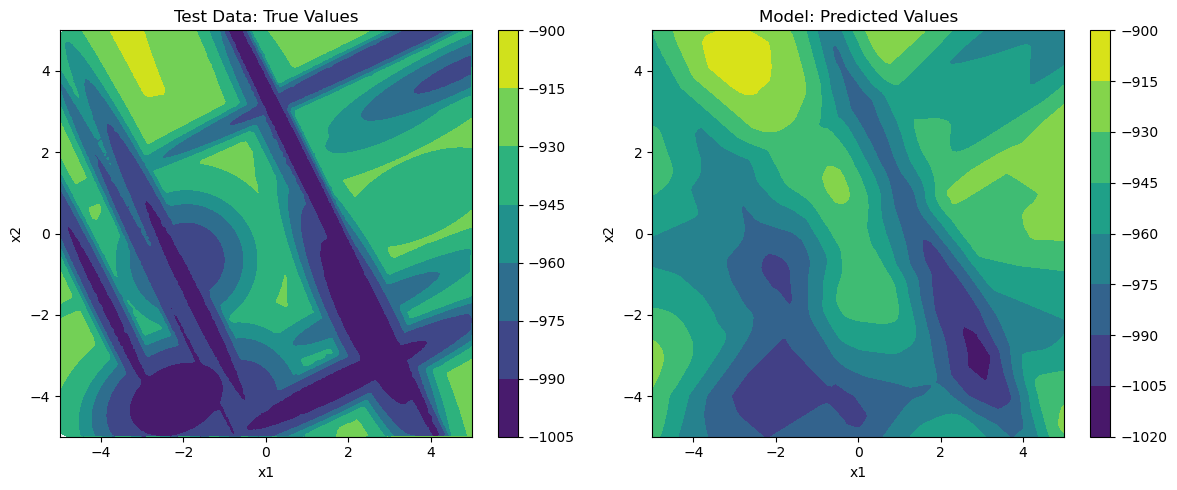

In [5]:
def plot_contour_comparison(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        test_inputs_list.append(inputs.cpu().numpy())
        test_targets_list.append(targets.cpu().numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()
    x1_vals = np.linspace(x1_min, x1_max, 100)
    x2_vals = np.linspace(x2_min, x2_max, 100)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.flatten(), X2.flatten()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        predictions = model(grid_tensor).cpu().numpy().flatten()

    Z_pred = predictions.reshape(X1.shape)

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    true_contour = ax1.tricontourf(
        test_inputs[:, 0], test_inputs[:, 1], test_targets.reshape(-1)
    )
    ax1.set_title("Test Data: True Values")
    ax1.set_xlabel("x1")
    ax1.set_ylabel("x2")
    plt.colorbar(true_contour, ax=ax1)

    pred_contour = ax2.contourf(X1, X2, Z_pred)
    ax2.set_title("Model: Predicted Values")
    ax2.set_xlabel("x1")
    ax2.set_ylabel("x2")
    plt.colorbar(pred_contour, ax=ax2)

    plt.tight_layout()
    plt.show()

plot_contour_comparison(model, test_dataloader, device)

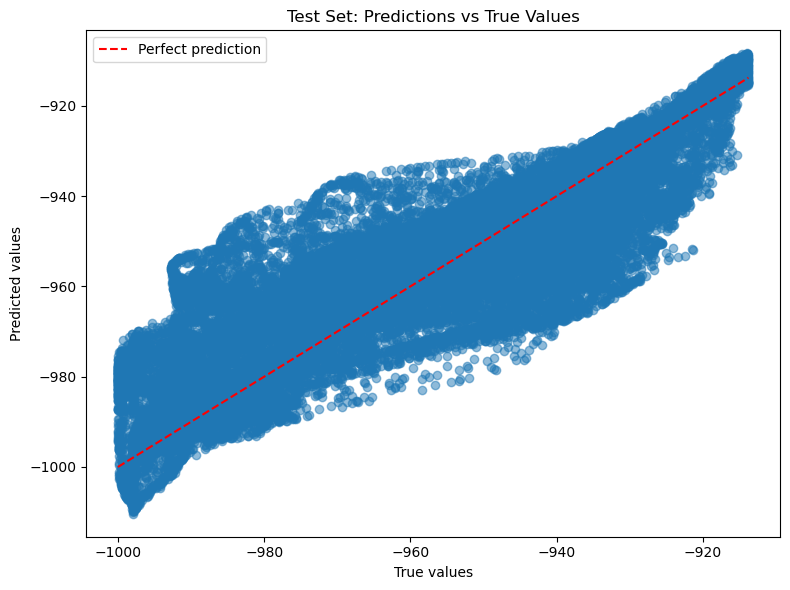

In [6]:
def plot_prediction_scatter(
    model: nn.Module, test_dataloader: DataLoader, device: torch.device
) -> None:
    test_targets_list = []
    test_preds_list = []

    for inputs, targets in test_dataloader:
        inputs, targets = inputs.to(device), targets.to(device)
        with torch.no_grad():
            outputs = model(inputs)

        test_targets_list.append(targets.cpu().numpy())
        test_preds_list.append(outputs.cpu().numpy())

    test_targets = np.concatenate(test_targets_list)
    test_preds = np.concatenate(test_preds_list).flatten()

    fig, ax = plt.subplots(figsize=(8, 6))
    ax.scatter(test_targets, test_preds, alpha=0.5)
    ax.plot(
        [test_targets.min(), test_targets.max()],
        [test_targets.min(), test_targets.max()],
        "r--",
        label="Perfect prediction",
    )
    ax.set_xlabel("True values")
    ax.set_ylabel("Predicted values")
    ax.set_title("Test Set: Predictions vs True Values")
    ax.legend()

    plt.tight_layout()
    plt.show()


plot_prediction_scatter(model, test_dataloader, device)

### 5. Gradient-Based Optimization

Now, we optimize the trained MLP to find the input that minimizes its output (our surrogate's prediction).

In [7]:
def optimize_model(
    model: nn.Module, num_steps: int = 1000
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()
    # Select random starting point in [-5, 5]^2
    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)
    raise NotImplementedError("Not implemented")
    optimizer = None # TODO: select optimizer

    for _ in range(num_steps):
        optimizer.zero_grad()
        # Predict output (our output - result of the model is the function we want to minimize)
        # Compute gradients (gradients of our model)
        # Update x
        # Enforce domain constraints [-5, 5]

### Exercise 1: Impact of Dataset Size
- **Task:** Train the MLP with different training set sizes (e.g., 100, 1000, 5000, 10000, 50000).
- **Instructions:**
  1. Modify the `train_perc` parameter in `prepare_dataloaders` to achieve these different dataset sizes (keep the test set size fixed at approximately 30,000 samples).
  2. Train the model for each dataset size and generate corresponding contour plots.
  3. Analyze how the MLP's ability to capture the underlying function structure (particularly the multimodal nature of f22) improves with increasing data volume.
  4. Select and justify a single quantitative metric that effectively captures the model’s predictive quality in this context. Use this metric to evaluate model performance across different training set sizes. Present the results as a plot to visualize how model quality scales with data availability.

### Exercise 2: Optimization Robustness
- **Task:** Implement the `optimize_model` function to find inputs that minimize the model's output.
- **Instructions:**
  1. Execute the optimization process multiple times (e.g. 10 for each dataset) with different random starting points and record the best surrogate values.
  2. Create a histogram of the best `y` values across all optimization runs to visualize the distribution of results.
  3. Generate a contour plot showing the locations of the solutions found. Analyze the consistency of these solutions.
  4. Use `cocoex` to evaluate the true objective function at the solution points. Compare these values against the surrogate’s predicted values.

### Accessing Original COCO Benchmark Problems

The code below installs and imports the necessary packages to access the original COCO benchmark problems (f1 and f22).
This will allow us to compare our model's predictions with the true functions and evaluate optimization performance.

In [13]:
from cocoex import Suite

function_id = 22  # Switch between 1 and 22 to change the function

suite = Suite(
    "bbob",
    "",
    f"function_indices: {function_id}, dimensions: 2 instance_indices: 1",
)
for function in suite:
    print(function.info)
    print("Function value at (0, 0):", function(np.array([0, 0])))

bbob_f022_i01_d02: a 2-dimensional single-objective problem (problem 315 of suite "b'bbob'" with name "BBOB suite problem f22 instance 1 in 2D")
Function value at (0, 0): -936.0557554469844



=== Training for train_size = 100 ===
Epoch 10/100 | Train Loss: 904268.625000 | Val Loss: 901740.111500
Epoch 20/100 | Train Loss: 877061.062500 | Val Loss: 871854.128200
Epoch 30/100 | Train Loss: 835211.625000 | Val Loss: 826415.344800
Epoch 40/100 | Train Loss: 775763.750000 | Val Loss: 762528.863800
Epoch 50/100 | Train Loss: 697181.937500 | Val Loss: 679000.048800
Epoch 60/100 | Train Loss: 600522.750000 | Val Loss: 577529.215700
Epoch 70/100 | Train Loss: 490467.250000 | Val Loss: 463734.550000
Epoch 80/100 | Train Loss: 375847.250000 | Val Loss: 347578.052200
Epoch 90/100 | Train Loss: 269044.281250 | Val Loss: 242408.986250
Epoch 100/100 | Train Loss: 183333.312500 | Val Loss: 161784.512675
Test RMSE for train_size=100: 401.489288


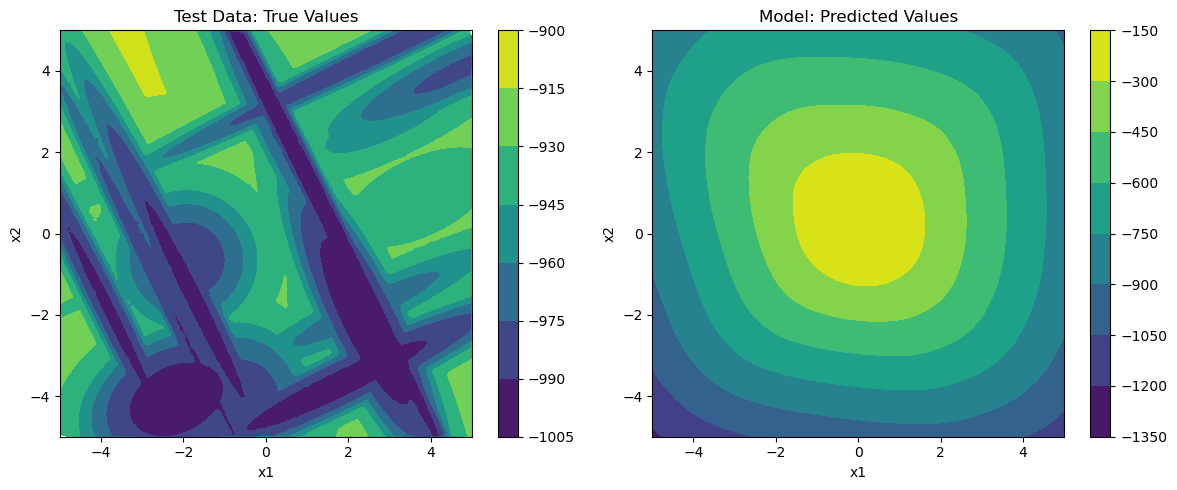


=== Training for train_size = 1000 ===
Epoch 10/100 | Train Loss: 795839.934500 | Val Loss: 779394.267900
Epoch 20/100 | Train Loss: 403648.117000 | Val Loss: 376347.642900
Epoch 30/100 | Train Loss: 100946.528000 | Val Loss: 94912.970138
Epoch 40/100 | Train Loss: 84521.062750 | Val Loss: 81185.250450
Epoch 50/100 | Train Loss: 79888.386563 | Val Loss: 77124.690362
Epoch 60/100 | Train Loss: 75266.403187 | Val Loss: 72647.137700
Epoch 70/100 | Train Loss: 70321.869625 | Val Loss: 67854.859075
Epoch 80/100 | Train Loss: 65006.156125 | Val Loss: 62700.552525
Epoch 90/100 | Train Loss: 59242.892625 | Val Loss: 57066.774925
Epoch 100/100 | Train Loss: 53018.727875 | Val Loss: 50980.491412
Test RMSE for train_size=1000: 223.867538


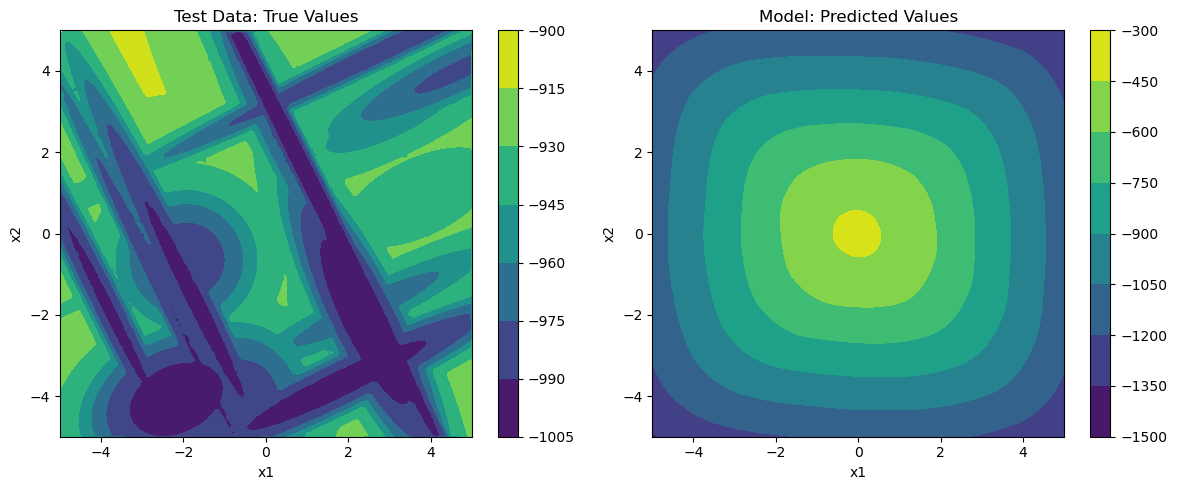


=== Training for train_size = 5000 ===
Epoch 10/100 | Train Loss: 79890.022150 | Val Loss: 78827.970425
Epoch 20/100 | Train Loss: 57289.508319 | Val Loss: 55711.891362
Epoch 30/100 | Train Loss: 26922.494381 | Val Loss: 25105.396847
Epoch 40/100 | Train Loss: 4417.518183 | Val Loss: 3819.439552
Epoch 50/100 | Train Loss: 608.000958 | Val Loss: 579.458272
Epoch 60/100 | Train Loss: 437.843084 | Val Loss: 438.408799
Epoch 70/100 | Train Loss: 394.562970 | Val Loss: 398.032593
Epoch 80/100 | Train Loss: 364.453978 | Val Loss: 368.283846
Epoch 90/100 | Train Loss: 337.473005 | Val Loss: 345.872680
Epoch 100/100 | Train Loss: 320.403575 | Val Loss: 331.209157
Test RMSE for train_size=5000: 18.155451


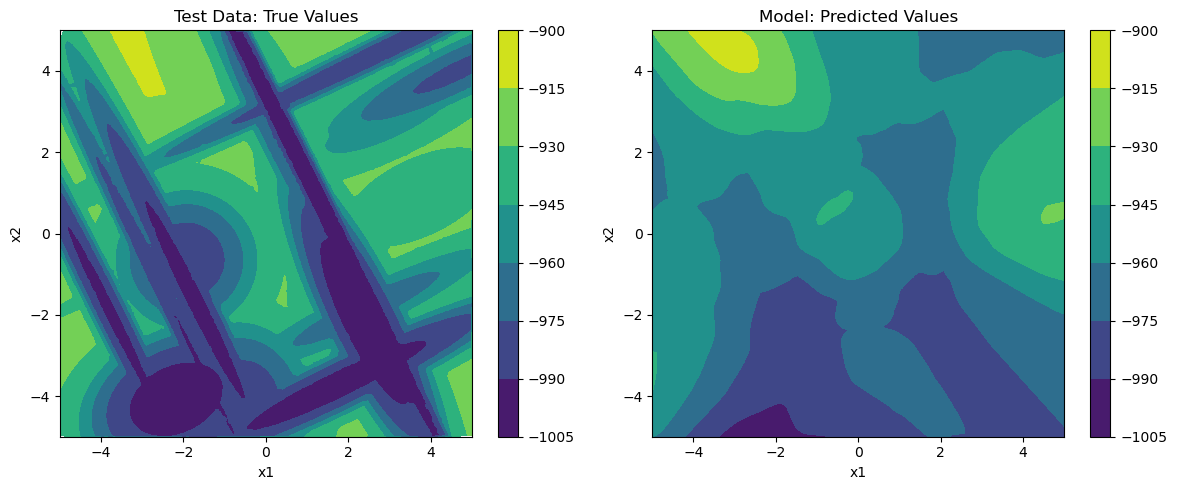


=== Training for train_size = 10000 ===
Epoch 10/100 | Train Loss: 57702.679175 | Val Loss: 53660.442637
Epoch 20/100 | Train Loss: 8479.637052 | Val Loss: 6988.511783
Epoch 30/100 | Train Loss: 555.469759 | Val Loss: 526.049785
Epoch 40/100 | Train Loss: 463.634597 | Val Loss: 451.402678
Epoch 50/100 | Train Loss: 434.940562 | Val Loss: 427.647938
Epoch 60/100 | Train Loss: 411.198703 | Val Loss: 399.361558
Epoch 70/100 | Train Loss: 391.563741 | Val Loss: 381.647099
Epoch 80/100 | Train Loss: 370.553073 | Val Loss: 360.029883
Epoch 90/100 | Train Loss: 353.678430 | Val Loss: 342.393399
Epoch 100/100 | Train Loss: 338.554996 | Val Loss: 328.756966
Test RMSE for train_size=10000: 18.281023


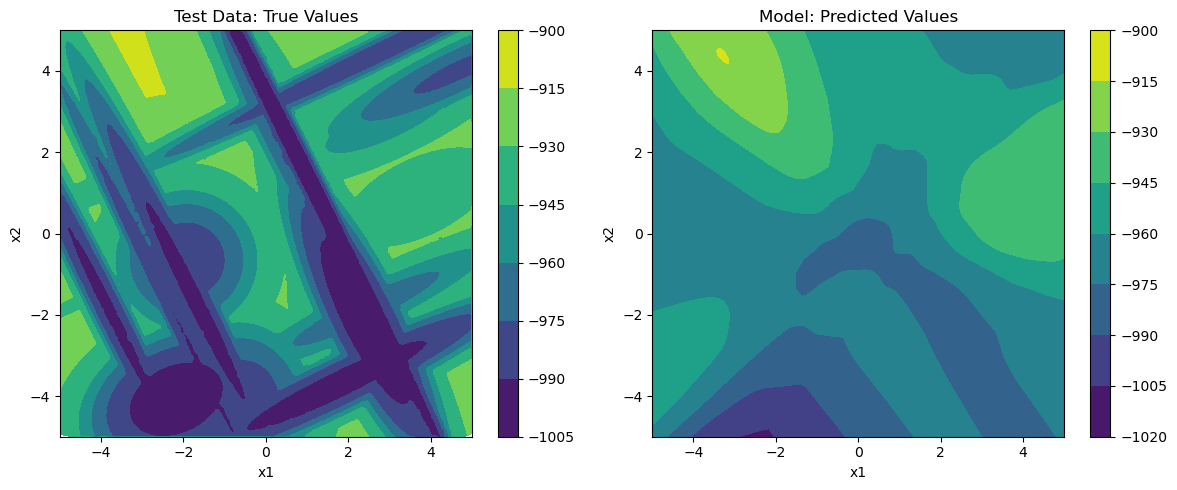


=== Training for train_size = 50000 ===
Epoch 10/100 | Train Loss: 354.592999 | Val Loss: 353.308021
Epoch 20/100 | Train Loss: 260.016030 | Val Loss: 253.611432
Epoch 30/100 | Train Loss: 209.541272 | Val Loss: 202.922655
Epoch 40/100 | Train Loss: 174.340257 | Val Loss: 177.719765
Epoch 50/100 | Train Loss: 155.628315 | Val Loss: 158.359620
Epoch 60/100 | Train Loss: 142.987899 | Val Loss: 136.589415
Epoch 70/100 | Train Loss: 135.174020 | Val Loss: 133.919051
Epoch 80/100 | Train Loss: 129.284335 | Val Loss: 126.191087
Epoch 90/100 | Train Loss: 121.208356 | Val Loss: 125.568307
Epoch 100/100 | Train Loss: 114.037849 | Val Loss: 111.319922
Test RMSE for train_size=50000: 10.566499


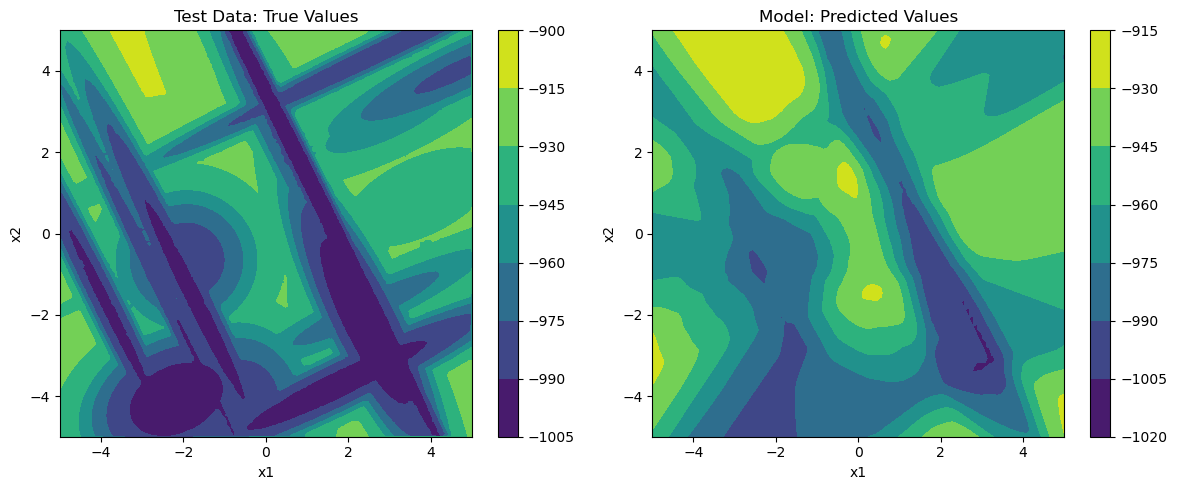

   train_size        rmse
0         100  401.489288
1        1000  223.867538
2        5000   18.155451
3       10000   18.281023
4       50000   10.566499


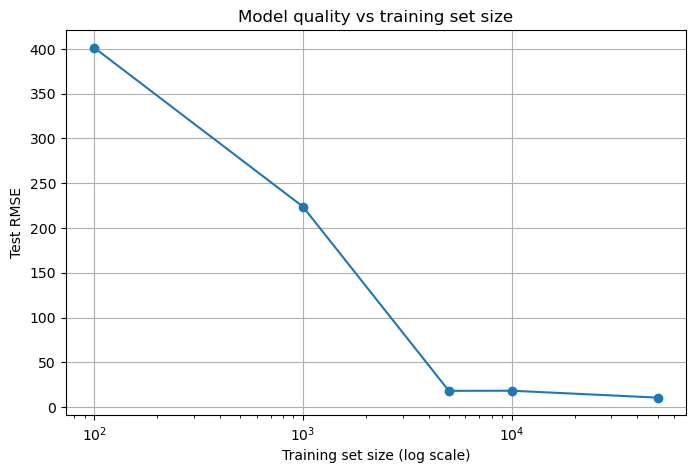

In [16]:
import math
from cocoex import Suite

torch.manual_seed(42)
np.random.seed(42)

FILE_PATH = "./bbob_f022_i01_d02_samples.csv"   
DATASET_SIZES = [100, 1000, 5000, 10000, 50000]
TEST_SIZE = 30000
VAL_SIZE = 10000
BATCH_SIZE = 256
NUM_EPOCHS = 100
LR = 1e-3


def prepare_dataloaders_fixed_sizes(
    file_path: str,
    train_size: int,
    val_size: int = 10000,
    test_size: int = 30000,
    batch_size: int = 256,
) -> tuple[DataLoader, DataLoader, DataLoader]:
    data_df = pd.read_csv(file_path)

    X = torch.tensor(data_df[["x1", "x2"]].values, dtype=torch.float32)
    y = torch.tensor(data_df["y"].values.reshape(-1, 1), dtype=torch.float32)

    n = len(X)
    assert train_size + val_size + test_size <= n, "Za mało danych dla takiego podziału."

    indices = np.random.permutation(n)

    train_idx = indices[:train_size]
    val_idx = indices[train_size : train_size + val_size]
    test_idx = indices[train_size + val_size : train_size + val_size + test_size]

    train_dataset = TensorDataset(X[train_idx], y[train_idx])
    val_dataset = TensorDataset(X[val_idx], y[val_idx])
    test_dataset = TensorDataset(X[test_idx], y[test_idx])

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, val_loader, test_loader


def train_model(
    train_dataloader: DataLoader,
    val_dataloader: DataLoader,
    hidden_dim: int = 256,
    n_layers: int = 3,
    num_epochs: int = 100,
    lr: float = 1e-3,
) -> tuple[nn.Module, list[float], list[float]]:
    model = MLP(input_dim=2, hidden_dim=hidden_dim, n_layers=n_layers).to(device)
    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    train_losses = []
    val_losses = []

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0.0

        for inputs, targets in train_dataloader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            train_loss += loss.item() * inputs.size(0)

        train_loss /= len(train_dataloader.dataset)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for inputs, targets in val_dataloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                loss = criterion(outputs, targets)
                val_loss += loss.item() * inputs.size(0)

        val_loss /= len(val_dataloader.dataset)
        val_losses.append(val_loss)

        if (epoch + 1) % 10 == 0:
            print(
                f"Epoch {epoch+1}/{num_epochs} | "
                f"Train Loss: {train_loss:.6f} | Val Loss: {val_loss:.6f}"
            )

    return model, train_losses, val_losses


def evaluate_rmse(model: nn.Module, dataloader: DataLoader) -> float:
    model.eval()
    ys_true, ys_pred = [], []

    with torch.no_grad():
        for inputs, targets in dataloader:
            inputs = inputs.to(device)
            outputs = model(inputs).cpu().numpy().reshape(-1)
            ys_pred.append(outputs)
            ys_true.append(targets.numpy().reshape(-1))

    ys_true = np.concatenate(ys_true)
    ys_pred = np.concatenate(ys_pred)
    rmse = np.sqrt(np.mean((ys_true - ys_pred) ** 2))
    return float(rmse)


results = []
models_by_size = {}

for train_size in DATASET_SIZES:
    print(f"\n=== Training for train_size = {train_size} ===")

    train_loader, val_loader, test_loader = prepare_dataloaders_fixed_sizes(
        file_path=FILE_PATH,
        train_size=train_size,
        val_size=VAL_SIZE,
        test_size=TEST_SIZE,
        batch_size=BATCH_SIZE,
    )

    model, train_losses, val_losses = train_model(
        train_dataloader=train_loader,
        val_dataloader=val_loader,
        num_epochs=NUM_EPOCHS,
        lr=LR,
    )

    rmse = evaluate_rmse(model, test_loader)
    print(f"Test RMSE for train_size={train_size}: {rmse:.6f}")

    results.append({"train_size": train_size, "rmse": rmse})
    models_by_size[train_size] = (model, test_loader)

    plot_contour_comparison(model, test_loader, device)

results_df = pd.DataFrame(results)
print(results_df)

plt.figure(figsize=(8, 5))
plt.plot(results_df["train_size"], results_df["rmse"], marker="o")
plt.xscale("log")
plt.xlabel("Training set size (log scale)")
plt.ylabel("Test RMSE")
plt.title("Model quality vs training set size")
plt.grid(True)
plt.show()

## Komentarz
Rrozmiar zbioru treningowego ma kluczowy wpływ na jakość modelu. Dla bardzo małych zbiorów model praktycznie nie jest w stanie uchwycić struktury funkcji – przewidywania odbiegają od rzeczywistego kształtu, co potwierdza bardzo wysoki RMSE.

Wraz ze wzrostem liczby danych następuje gwałtowna poprawa - model zaczyna odwzorowywać bardziej złożone, lokalne struktury funkcji, a błąd spada. Dalsze zwiększenie zbioru  przynosi już mniejsze, ale nadal zauważalne ulepszenia.

In [17]:
def optimize_model(
    model: nn.Module, num_steps: int = 1000, lr: float = 0.05
) -> tuple[torch.Tensor, float]:
    """
    Perform gradient-based optimization on the MLP.

    Args:
        model (nn.Module): Trained MLP model.
        num_steps (int): Number of optimization steps.
        lr (float): Learning rate.

    Returns:
        tuple: (best_x, best_y) - Optimal input and its predicted output.
    """
    model.eval()

    x = torch.rand(1, 2, device=device) * 10 - 5
    x.requires_grad_(True)

    optimizer = torch.optim.Adam([x], lr=lr)

    best_x = x.detach().clone()
    best_y = float("inf")

    for _ in range(num_steps):
        optimizer.zero_grad()

        y_pred = model(x)
        y_pred.backward()
        optimizer.step()

        with torch.no_grad():
            x.clamp_(-5.0, 5.0)
            current_y = model(x).item()

            if current_y < best_y:
                best_y = current_y
                best_x = x.detach().clone()

    return best_x, best_y


=== Optimization robustness for train_size = 100 ===


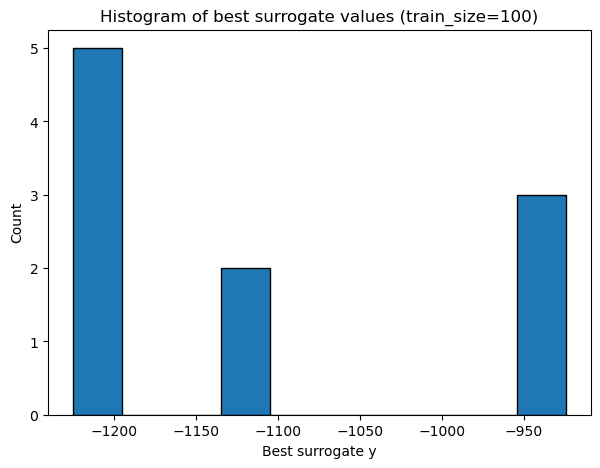

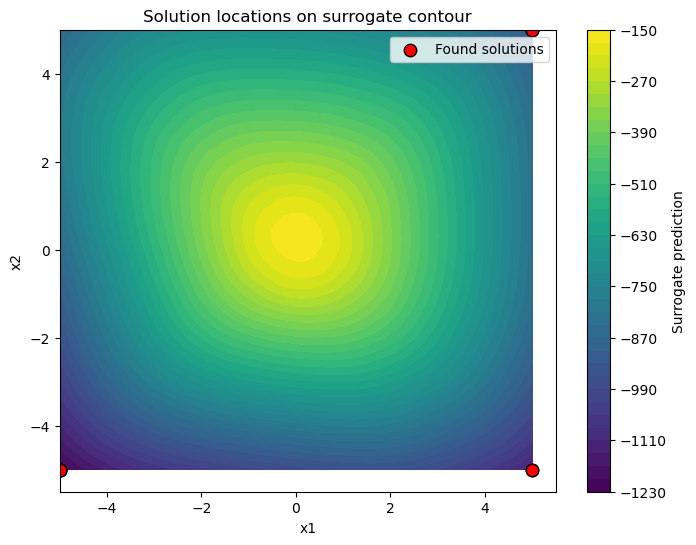

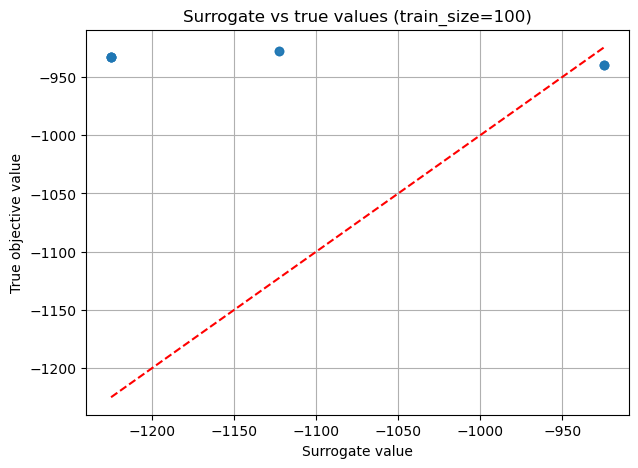


=== Optimization robustness for train_size = 1000 ===


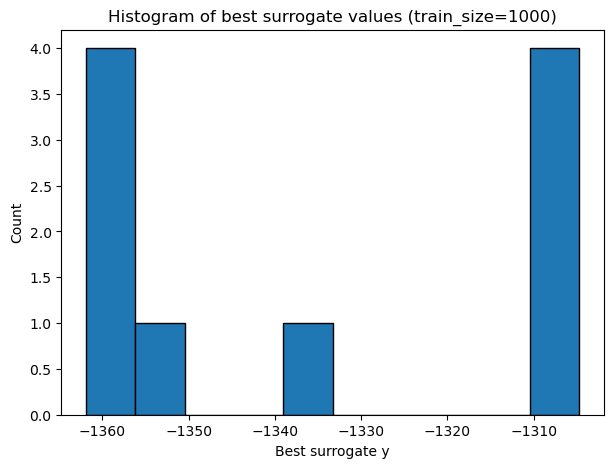

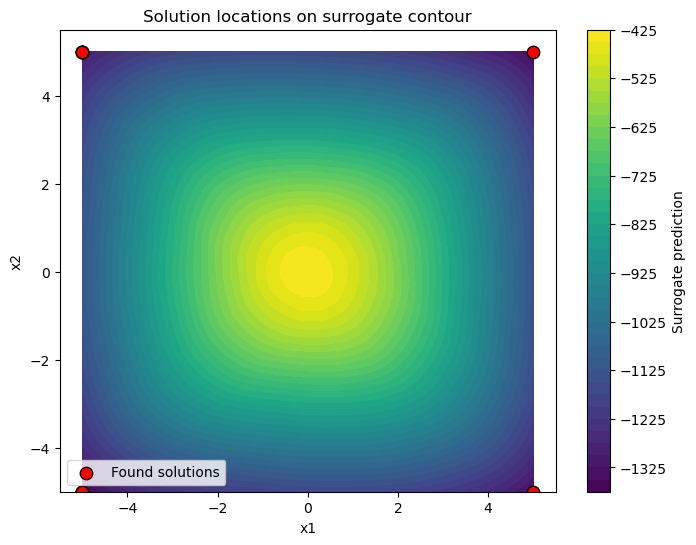

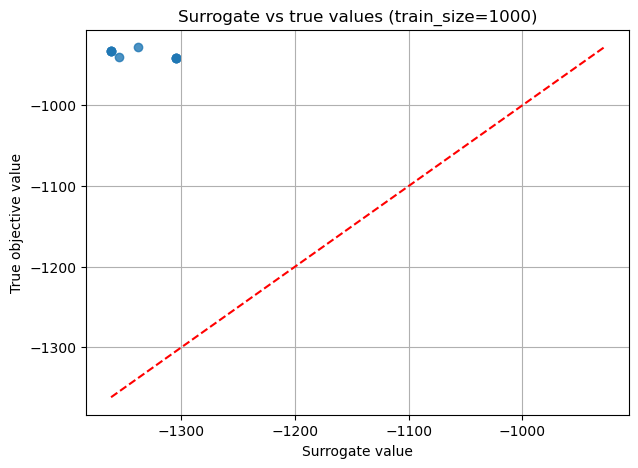


=== Optimization robustness for train_size = 5000 ===


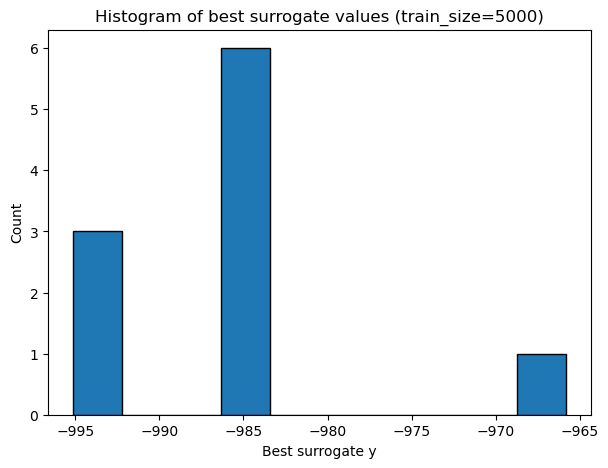

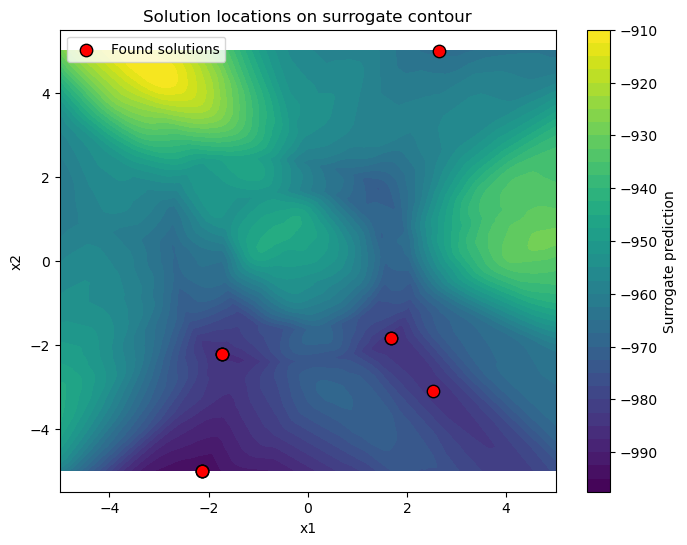

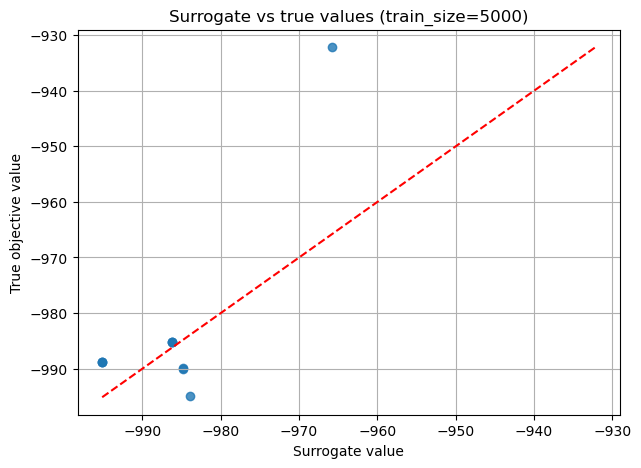


=== Optimization robustness for train_size = 10000 ===


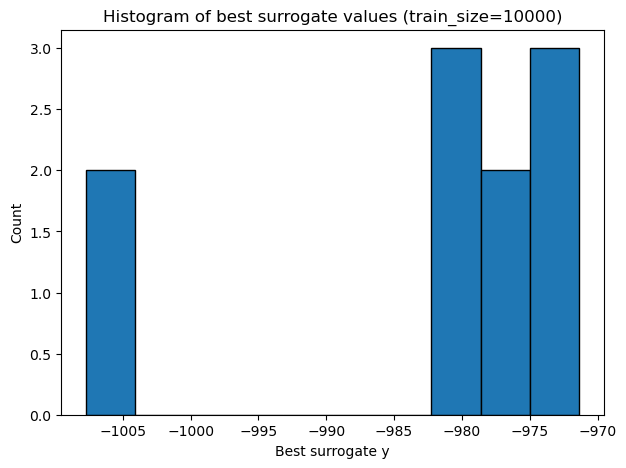

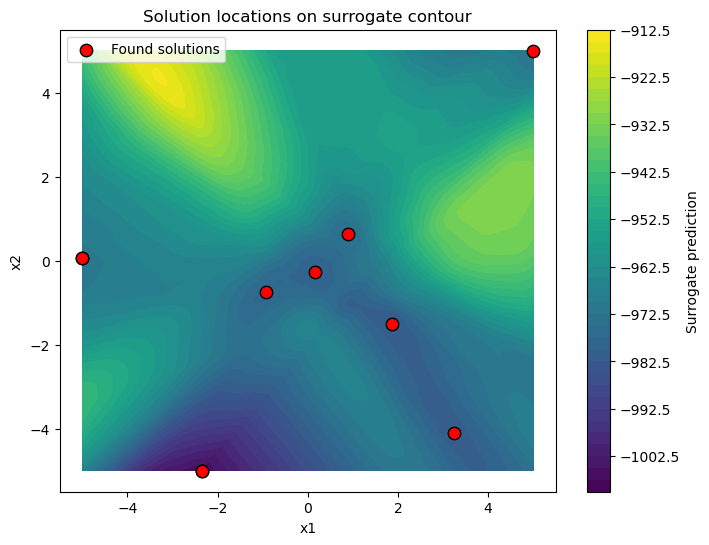

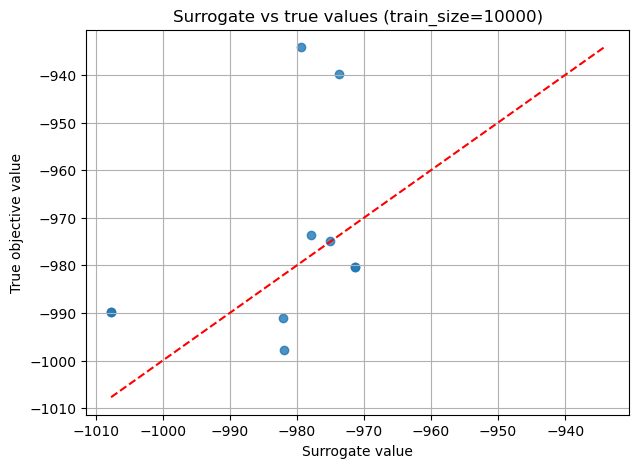


=== Optimization robustness for train_size = 50000 ===


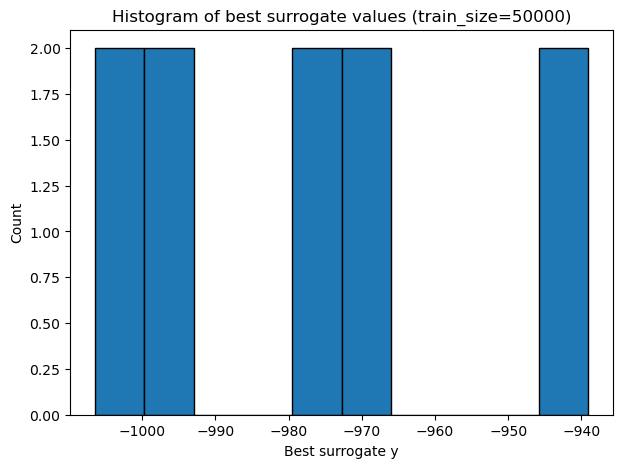

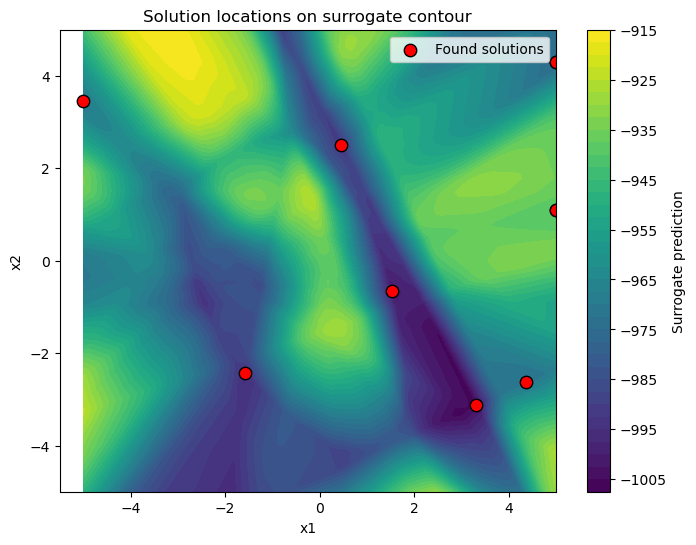

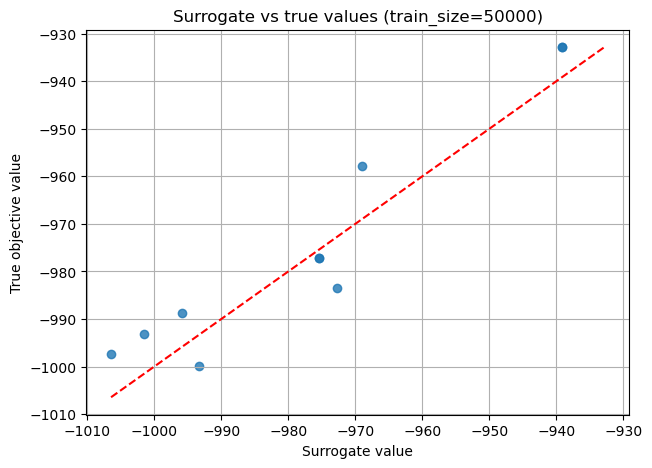

    train_size  run        x1        x2  surrogate_y      true_y
0          100    1 -5.000000 -5.000000 -1225.116943 -932.670594
1          100    2 -5.000000 -5.000000 -1225.116943 -932.670594
2          100    3  5.000000  5.000000  -924.323486 -939.825304
3          100    4  5.000000  5.000000  -924.323486 -939.825304
4          100    5 -5.000000 -5.000000 -1225.116943 -932.670594
5          100    6  5.000000  5.000000  -924.323486 -939.825304
6          100    7 -5.000000 -5.000000 -1225.116943 -932.670594
7          100    8 -5.000000 -5.000000 -1225.116943 -932.670594
8          100    9  5.000000 -5.000000 -1122.889404 -927.878833
9          100   10  5.000000 -5.000000 -1122.889404 -927.878833
10        1000    1 -5.000000  5.000000 -1304.715454 -941.470942
11        1000    2  5.000000  5.000000 -1354.528931 -939.825304
12        1000    3 -5.000000  5.000000 -1304.715454 -941.470942
13        1000    4 -5.000000 -5.000000 -1361.891602 -932.670594
14        1000    5 -5.00

In [18]:
FUNCTION_ID = 22   #1 albo 22
N_RUNS = 10

suite = Suite(
    "bbob",
    "",
    f"function_indices: {FUNCTION_ID}, dimensions: 2 instance_indices: 1",
)
true_function = next(iter(suite))


def plot_solution_locations(model, test_dataloader, solution_points, device):
    test_inputs_list = []
    test_targets_list = []

    for inputs, targets in test_dataloader:
        test_inputs_list.append(inputs.numpy())
        test_targets_list.append(targets.numpy())

    test_inputs = np.vstack(test_inputs_list)
    test_targets = np.concatenate(test_targets_list).reshape(-1)

    x1_min, x1_max = test_inputs[:, 0].min(), test_inputs[:, 0].max()
    x2_min, x2_max = test_inputs[:, 1].min(), test_inputs[:, 1].max()

    x1_vals = np.linspace(x1_min, x1_max, 200)
    x2_vals = np.linspace(x2_min, x2_max, 200)
    X1, X2 = np.meshgrid(x1_vals, x2_vals)

    grid_points = np.column_stack((X1.ravel(), X2.ravel()))
    grid_tensor = torch.tensor(grid_points, dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        Z = model(grid_tensor).cpu().numpy().reshape(X1.shape)

    solution_points = np.array(solution_points)

    plt.figure(figsize=(8, 6))
    plt.contourf(X1, X2, Z, levels=40)
    plt.colorbar(label="Surrogate prediction")
    plt.scatter(
        solution_points[:, 0],
        solution_points[:, 1],
        c="red",
        edgecolors="black",
        s=80,
        label="Found solutions",
    )
    plt.xlabel("x1")
    plt.ylabel("x2")
    plt.title("Solution locations on surrogate contour")
    plt.legend()
    plt.show()


robustness_results = []

for train_size in DATASET_SIZES:
    print(f"\n=== Optimization robustness for train_size = {train_size} ===")

    model, test_loader = models_by_size[train_size]

    best_points = []
    surrogate_values = []
    true_values = []

    for run in range(N_RUNS):
        best_x, best_y = optimize_model(model, num_steps=1000, lr=0.05)

        x_np = best_x.detach().cpu().numpy().reshape(-1)
        true_y = float(true_function(x_np))

        best_points.append(x_np)
        surrogate_values.append(best_y)
        true_values.append(true_y)

        robustness_results.append(
            {
                "train_size": train_size,
                "run": run + 1,
                "x1": x_np[0],
                "x2": x_np[1],
                "surrogate_y": best_y,
                "true_y": true_y,
            }
        )

    # histogram surrogate values
    plt.figure(figsize=(7, 5))
    plt.hist(surrogate_values, bins=10, edgecolor="black")
    plt.xlabel("Best surrogate y")
    plt.ylabel("Count")
    plt.title(f"Histogram of best surrogate values (train_size={train_size})")
    plt.show()

    # contour with found points
    plot_solution_locations(model, test_loader, best_points, device)

    # surrogate vs true
    plt.figure(figsize=(7, 5))
    plt.scatter(surrogate_values, true_values, alpha=0.8)
    min_v = min(min(surrogate_values), min(true_values))
    max_v = max(max(surrogate_values), max(true_values))
    plt.plot([min_v, max_v], [min_v, max_v], "r--")
    plt.xlabel("Surrogate value")
    plt.ylabel("True objective value")
    plt.title(f"Surrogate vs true values (train_size={train_size})")
    plt.grid(True)
    plt.show()

results_robust_df = pd.DataFrame(robustness_results)
print(results_robust_df)

summary_df = (
    results_robust_df.groupby("train_size")[["surrogate_y", "true_y"]]
    .agg(["mean", "std", "min", "max"])
)
print(summary_df)

## Wnioski
Wyniki pokazują, że jakość optymalizacji silnie zależy od jakości modelu zastępczego. Dla małych zbiorów rozwiązania skupiają się w niewłaściwych obszarach, a wartości przewidywane przez model znacząco odbiegają od rzeczywistych, co widać na dużym rozrzucie względem linii idealnej.

Wraz ze wzrostem liczby danych rozwiązania zaczynają koncentrować się w bardziej sensownych regionach, a zgodność między wartością surrogate a prawdziwą funkcją wyraźnie się poprawia. Histogramy stają się bardziej skupione, co wskazuje na większą stabilność.

Dla największego zbioru punkty rozwiązań grupują się w podobnych obszarach, a przewidywania modelu są dobrze skorelowane z rzeczywistymi wartościami. Mimo to nadal widać pewne odchylenia, co pokazuje, że nawet dobry model może prowadzić do lekkiego błędu.